In [1]:
!pip install stable-baselines3[extra]
!pip install gymnasium[mujoco]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 23.0 MB/s eta 0:00:00


In [2]:
import os
import random
import time

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from stable_baselines3.common.buffers import ReplayBuffer

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# settings
env_id = "HalfCheetah-v5"

# total number of timesteps for training over multiple episodes
total_timesteps = 50_000

# adam learning rate
learning_rate = 3e-4

# number of transitions to store in the replay buffer
buffer_size = 1_000_000

# discount factor
gamma = 0.99

# target network update constant
# θ_target = 𝜏 * θ + (1 - 𝜏) * θ_target
tau = 0.005

# number of timesteps between target network and policy updates
policy_update_period = 2

# size of sample from replay buffer
batch_size = 256

# number of steps before beginning training
num_steps_before_training = 25_000

# optional: set seed for reproducibility
seed = None

# standard deviation of exploration noise
exploration_sd = 0.1


In [4]:
def make_env(env_id, capture_video, seed=None):
  if capture_video:
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(
        env,
        "ddpg_videos",
        episode_trigger=lambda episode: True)
  else:
    env = gym.make(env_id)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  obs_space = env.observation_space
  env = gym.wrappers.TransformObservation(
      env,
      lambda obs: obs.astype(np.float32),
      observation_space=gym.spaces.Box(
          low=obs_space.low,
          high=obs_space.high,
          shape=obs_space.shape,
          dtype=np.float32,
      ),
  )

  if seed is not None:
    env.action_space.seed(seed)
  return env


In [5]:
class QNetwork(nn.Module):
  def __init__(self, env):
    super().__init__()
    n_inputs = np.prod(env.single_observation_space.shape) + \
      np.prod(env.single_action_space.shape)
    self.fc1 = nn.Linear(n_inputs, 256)
    self.fc2 = nn.Linear(256, 256)
    self.fc3 = nn.Linear(256, 1)

  def forward(self, obs, action):
    x = torch.cat([obs, action], dim=-1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [6]:
class Actor(nn.Module):
  def __init__(self, env):
    super().__init__()
    self.fc1 = nn.Linear(np.prod(env.single_observation_space.shape), 256)
    self.fc2 = nn.Linear(256, 256)
    self.fc3 = nn.Linear(256, np.prod(env.single_action_space.shape))

  def forward(self, obs):
    x = F.relu(self.fc1(obs))
    x = F.relu(self.fc2(x))
    x = torch.tanh(self.fc3(x))
    return x

In [7]:
# optional: set seeds for reproducibility
if seed is not None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

In [8]:
envs = gym.vector.SyncVectorEnv(
    [lambda: make_env(env_id, capture_video=False, seed=seed)],
    autoreset_mode=gym.vector.AutoresetMode.SAME_STEP,
)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [10]:
# make actor networks
actor = Actor(envs).to(device)
actor_target = Actor(envs).to(device)
actor_target.load_state_dict(actor.state_dict())

<All keys matched successfully>

In [11]:
# make q networks
q_network = QNetwork(envs).to(device)
q_target = QNetwork(envs).to(device)
q_target.load_state_dict(q_network.state_dict())

<All keys matched successfully>

In [12]:
# make optimizers
actor_optimizer = optim.Adam(actor.parameters(), lr=learning_rate)
q_optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# default is to return float64 which needs to be cast for GPU/MPS
envs.single_observation_space.dtype = np.float32

In [14]:
rb = ReplayBuffer(
    buffer_size=buffer_size,
    observation_space=envs.single_observation_space,
    action_space=envs.single_action_space,
    device=device,
    handle_timeout_termination=False,
)

In [15]:
start_time = time.time()
episode_returns = []
obs, _ = envs.reset()
for global_step in range(total_timesteps):
  # select action
  if global_step < num_steps_before_training:
    actions = np.array([
        envs.single_action_space.sample()
        for _ in range(envs.num_envs)
    ])
  else:
    with torch.no_grad():
      actions = actor(torch.as_tensor(obs).to(device))
      actions += torch.randn_like(actions, device=device) * exploration_sd
      actions = actions.cpu().numpy()

  # clip actions b/c we added noise
  actions = actions.clip(
          envs.single_action_space.low,
          envs.single_action_space.high,
  )

  # take a step in the environment
  next_obs, rewards, terminateds, truncateds, infos = envs.step(actions)

  # store and print episode return
  if "final_info" in infos:
    ret = infos["final_info"]["episode"]["r"][0]
    print(f"global_step={global_step}, episode return: {ret}")
    episode_returns.append(ret)

  # since we use same step
  real_next_obs = next_obs.copy()
  for i, truncated in enumerate(truncateds):
    if truncated:
      real_next_obs[i] = infos["final_obs"][i]
  rb.add(obs, real_next_obs, actions, rewards, terminateds, infos)

  # don't forget!
  obs = next_obs

  # training
  if global_step > num_steps_before_training:
    data = rb.sample(batch_size)

    # we'll train the q network on every step
    with torch.no_grad():
      a2 = actor_target(data.next_observations)
      q2 = q_target(data.next_observations, a2)
      td_target = data.rewards.flatten() + gamma * q2.view(-1) * \
        (1 - data.dones.flatten())

    q_pred = q_network(data.observations, data.actions).view(-1)
    q_loss = F.mse_loss(q_pred, td_target)

    # gradient descent step
    q_optimizer.zero_grad()
    q_loss.backward()
    q_optimizer.step()

    # we'll train the actor every `policy_update_period` steps
    # and update target networks
    if global_step % policy_update_period == 0:
      actor_loss = -q_network(data.observations, actor(data.observations)).mean()
      actor_optimizer.zero_grad()
      actor_loss.backward()
      actor_optimizer.step()

      # update target networks
      for param, target_param in zip(
          q_network.parameters(), q_target.parameters()
      ):
        target_param.data.copy_(
            tau * param.data + (1 - tau) * target_param.data
        )
      for param, target_param in zip(
          actor.parameters(), actor_target.parameters()
      ):
        target_param.data.copy_(
            tau * param.data + (1 - tau) * target_param.data
        )

    if global_step % 100 == 0:
      print(f"steps per second:", int(global_step / (time.time() - start_time)))

# close env
envs.close()
print("total time (mins):", (time.time() - start_time) / 60)

global_step=999, episode return: -253.30384949810698
global_step=1999, episode return: -242.2347594263958
global_step=2999, episode return: -231.89953315002816
global_step=3999, episode return: -274.24363868758724
global_step=4999, episode return: -423.4075384377594
global_step=5999, episode return: -226.6817899339924
global_step=6999, episode return: -342.21763230397084
global_step=7999, episode return: -418.75578499848734
global_step=8999, episode return: -238.3980778564157
global_step=9999, episode return: -216.32203713267407
global_step=10999, episode return: -249.504345477942
global_step=11999, episode return: -192.6265842609631
global_step=12999, episode return: -251.96543990681772
global_step=13999, episode return: -397.95572177400555
global_step=14999, episode return: -305.6415800593059
global_step=15999, episode return: -348.4003849487179
global_step=16999, episode return: -278.28828417982936
global_step=17999, episode return: -358.2941691340441
global_step=18999, episode retu

Text(0, 0.5, 'Return')

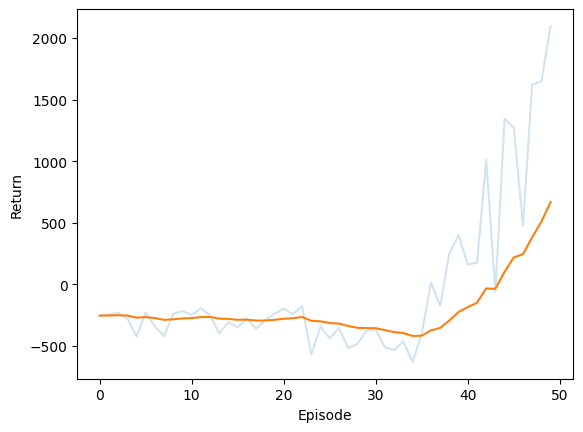

In [16]:
def smooth(x, a=0.1):
  y = [x[0]]
  for xi in x[1:]:
    yi = a * xi + (1 - a) * y[-1]
    y.append(yi)
  return y

plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.xlabel("Episode")
plt.ylabel("Return")

In [17]:
# save models
model_path = "ddpg_actor.pth"
torch.save(actor.state_dict(), model_path)

In [19]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)],
  autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
model = Actor(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


<All keys matched successfully>

In [20]:
# colab only

import os

# Set MuJoCo to use EGL for headless rendering
os.environ['MUJOCO_GL'] = 'egl'

# Optional: Set PyOpenGL to use EGL as well
os.environ['PYOPENGL_PLATFORM'] = 'egl'

In [21]:
!apt-get update -y
!apt-get install -y libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,302 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,630 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-dr

In [24]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    with torch.no_grad():
      action = model(torch.as_tensor(obs).to(device))
      action = action.cpu().numpy()
    obs, rewards, terminateds, truncateds, infos = envs_eval.step(action)

    if terminateds[0] or truncateds[0]:
      if 'final_info' in infos:
        if 'episode' in infos['final_info']:
          episode_done = True
          ret = infos['final_info']['episode']['r'][0]
          print(f"episode return: {ret}")
          eval_returns[i] = ret
        else:
          print("episode not in final_info:", infos)
      else:
        print("final_info not in infos:", infos)

envs_eval.close()

episode return: 1886.6219534167635
episode return: 2031.2545540035865
episode return: 1904.1488538057122
episode return: 1824.0780111987967
episode return: 1980.432635243294
episode return: 2045.7587452614189
episode return: 2181.499105839064
episode return: 1985.062540343405
episode return: 2186.249956949404
episode return: 2032.5304912713746


Text(0, 0.5, 'Frequency')

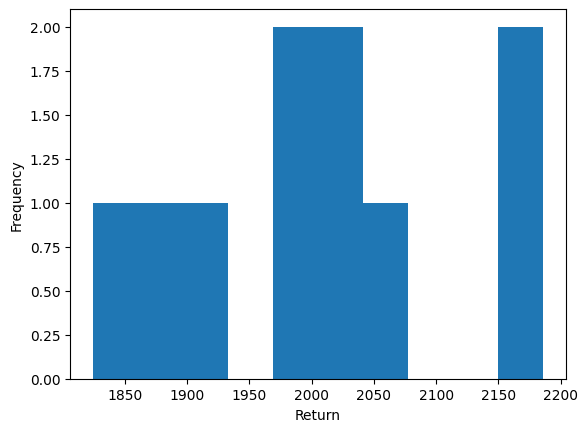

In [25]:
# plot eval return distribution
plt.hist(eval_returns)
plt.xlabel("Return")
plt.ylabel("Frequency")

In [ ]:
# play video


In [26]:
from IPython.display import Video, display

display(Video("/content/ddpg_videos/rl-video-episode-0.mp4", embed=True))

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=ajMgus4HVOdGR3CZkAAu7w&n=DDPG+MuJoCo)